In [1]:
!pip install -q shap kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 3.7 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import time
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, precision_recall_curve, classification_report,
    matthews_corrcoef, balanced_accuracy_score
)
from sklearn.inspection import permutation_importance

import xgboost as xgb
from lightgbm import LGBMClassifier

import shap

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

os.makedirs("figures", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

print("Libraries imported successfully.")

Libraries imported successfully.


# Load Dataset

In [3]:
DATA_PATH = "online_shoppers_intention.csv"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())
display(df.tail())
print("\nColumns:\n", df.columns.tolist())
print("\nInfo:")
df.info()
display(df.describe(include="all").T)
print("\nData types:\n", df.dtypes)

Shape: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False
12329,0,0.0,0,0.0,3,21.250000,0.000000,0.066667,0.000000,0.0,Nov,3,2,1,2,New_Visitor,True,False



Columns:
 ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-n

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Administrative,12330.0,NaN,NaN,NaN,2.315166,3.321784,0.0,0.0,1.0,4.0,27.0
Administrative_Duration,12330.0,NaN,NaN,NaN,80.818611,176.779107,0.0,0.0,7.5,93.25625,3398.75
Informational,12330.0,NaN,NaN,NaN,0.503569,1.270156,0.0,0.0,0.0,0.0,24.0
Informational_Duration,12330.0,NaN,NaN,NaN,34.472398,140.749294,0.0,0.0,0.0,0.0,2549.375
ProductRelated,12330.0,NaN,NaN,NaN,31.731468,44.475503,0.0,7.0,18.0,38.0,705.0
ProductRelated_Duration,12330.0,NaN,NaN,NaN,1194.74622,1913.669288,0.0,184.1375,598.936905,1464.157214,63973.52223
BounceRates,12330.0,NaN,NaN,NaN,0.022191,0.048488,0.0,0.0,0.003112,0.016813,0.2
ExitRates,12330.0,NaN,NaN,NaN,0.043073,0.048597,0.0,0.014286,0.025156,0.05,0.2
PageValues,12330.0,NaN,NaN,NaN,5.889258,18.568437,0.0,0.0,0.0,0.0,361.763742
SpecialDay,12330.0,NaN,NaN,NaN,0.061427,0.198917,0.0,0.0,0.0,0.0,1.0



Data types:
 Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object


# Exploratory Data Analysis

Missing Values Table:


'No missing values found.'

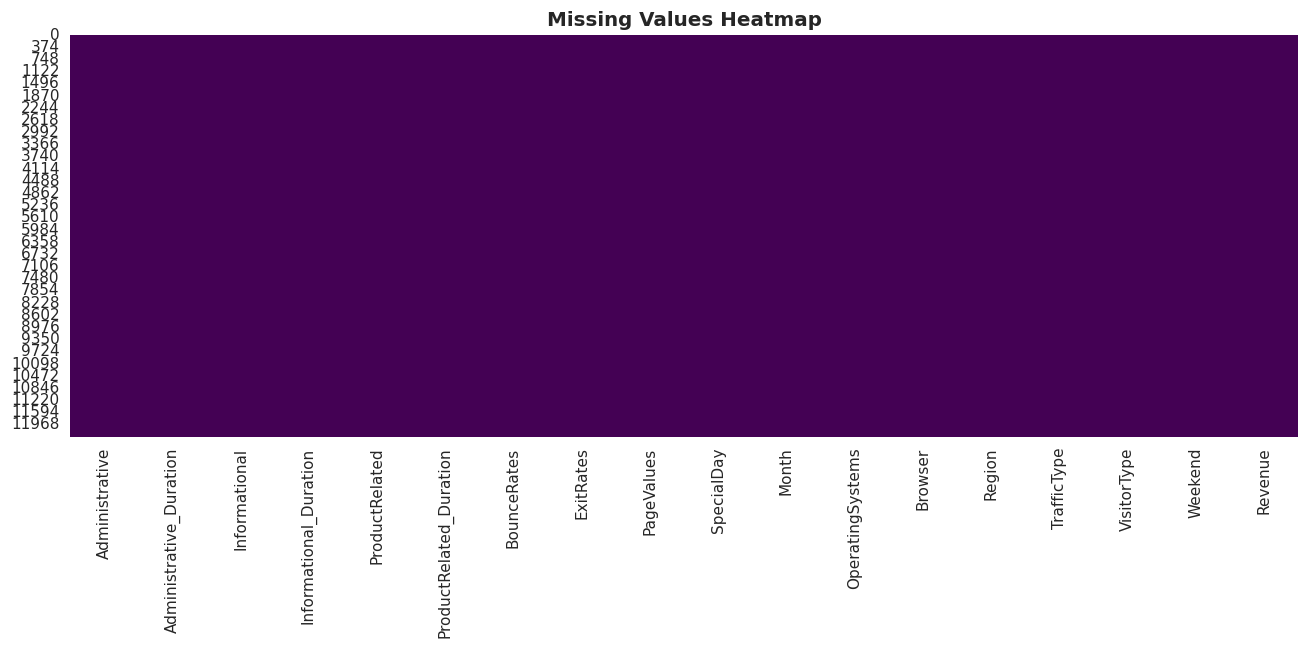

Duplicate rows: 125


In [4]:
def missing_values_table(data):
    miss = data.isnull().sum()
    pct = (miss / len(data)) * 100
    table = pd.DataFrame({"Missing Count": miss, "Missing %": pct})
    return table[table["Missing Count"] > 0].sort_values("Missing %", ascending=False)

miss_table = missing_values_table(df)
print("Missing Values Table:")
display(miss_table if not miss_table.empty else "No missing values found.")

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.tight_layout()
plt.savefig("figures/01_missing_heatmap.png")
plt.show()

dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")

## target distribution & class imbalance

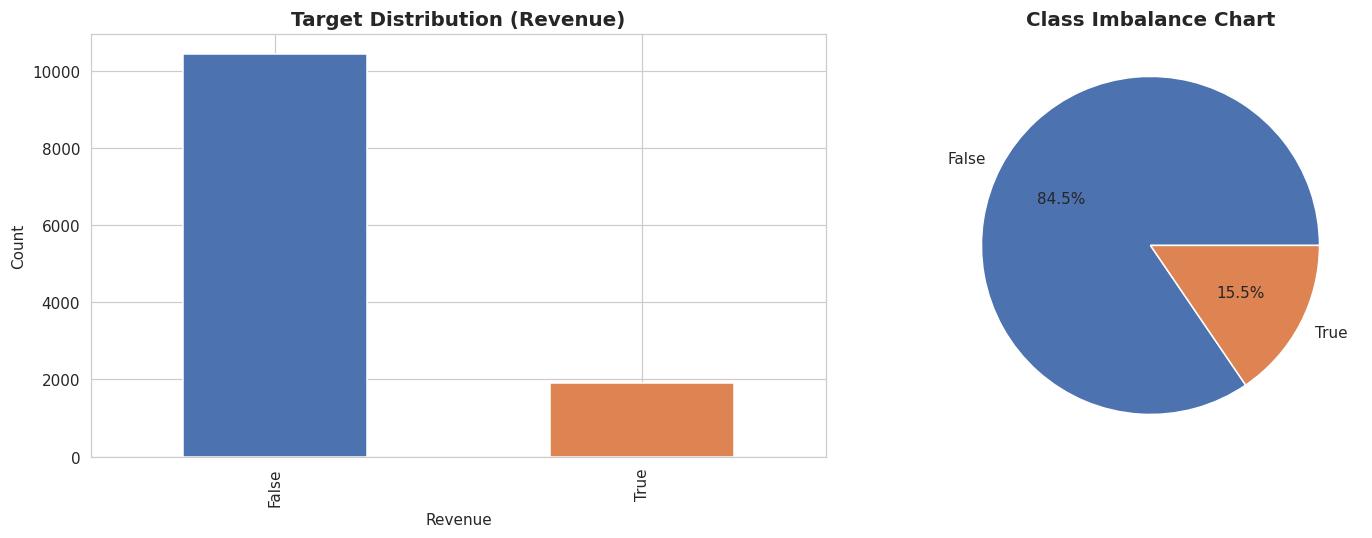

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
df["Revenue"].value_counts().plot(kind="bar", ax=ax[0], color=["#4C72B0", "#DD8452"])
ax[0].set_title("Target Distribution (Revenue)")
ax[0].set_xlabel("Revenue"); ax[0].set_ylabel("Count")

df["Revenue"].value_counts(normalize=True).plot(kind="pie", autopct="%1.1f%%", ax=ax[1],
    colors=["#4C72B0", "#DD8452"])
ax[1].set_title("Class Imbalance Chart")
ax[1].set_ylabel("")
plt.tight_layout()
plt.savefig("figures/02_target_distribution.png")
plt.show()

## numerical histograms

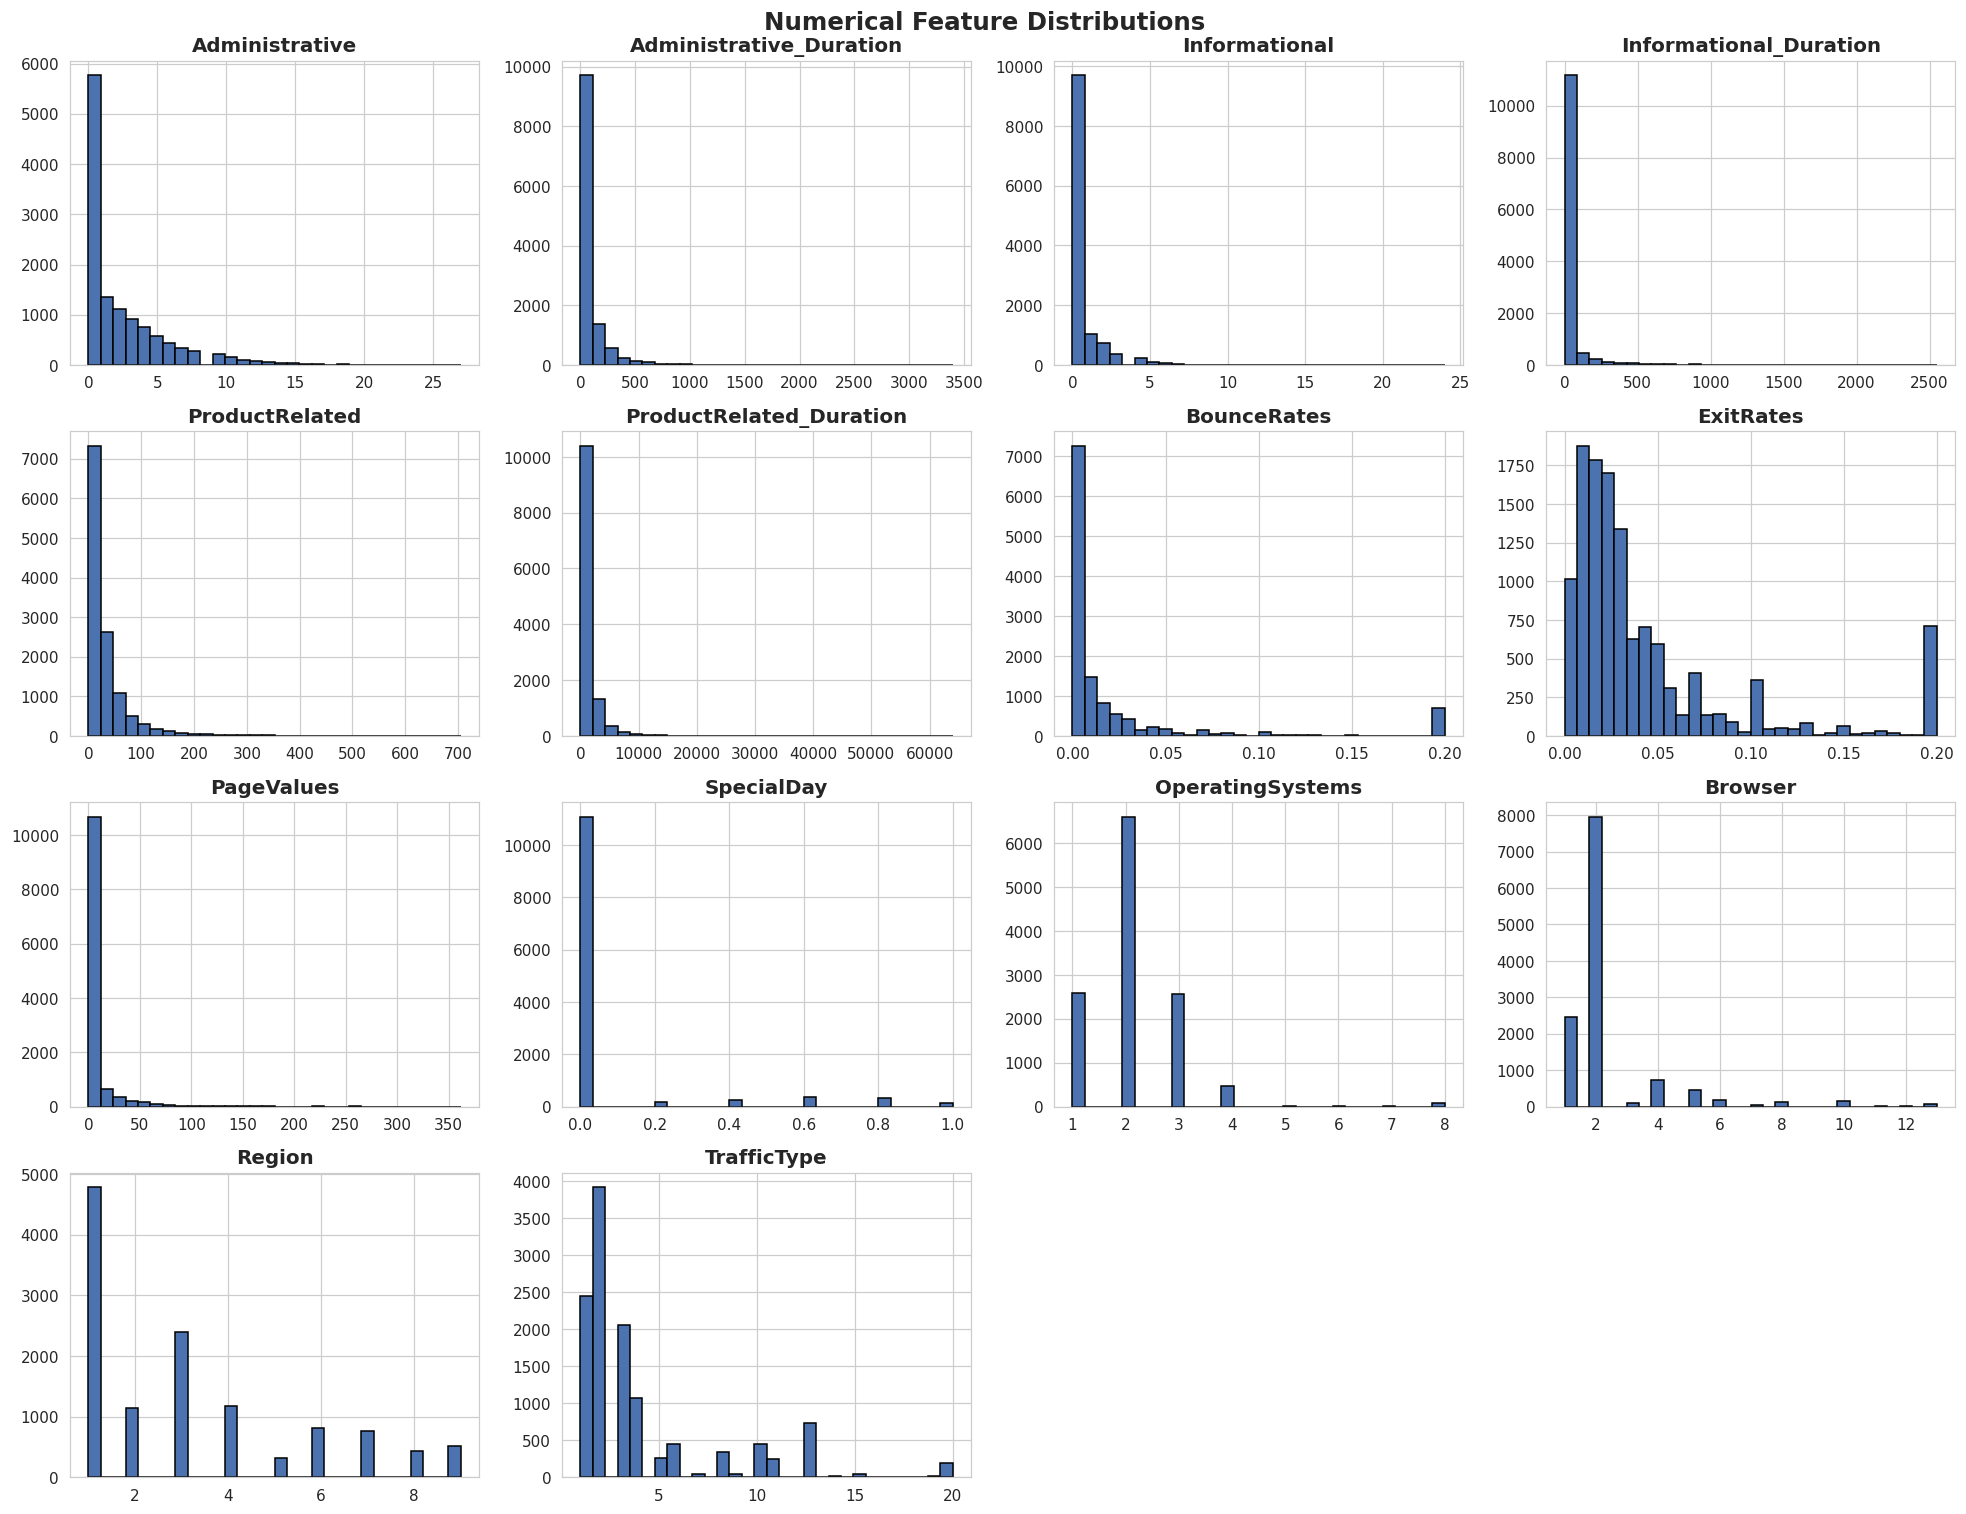

In [6]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

df[num_cols].hist(figsize=(18, 14), bins=30, color="#4C72B0", edgecolor="black")
plt.suptitle("Numerical Feature Distributions", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/03_numerical_histograms.png")
plt.show()

## categorical countplots

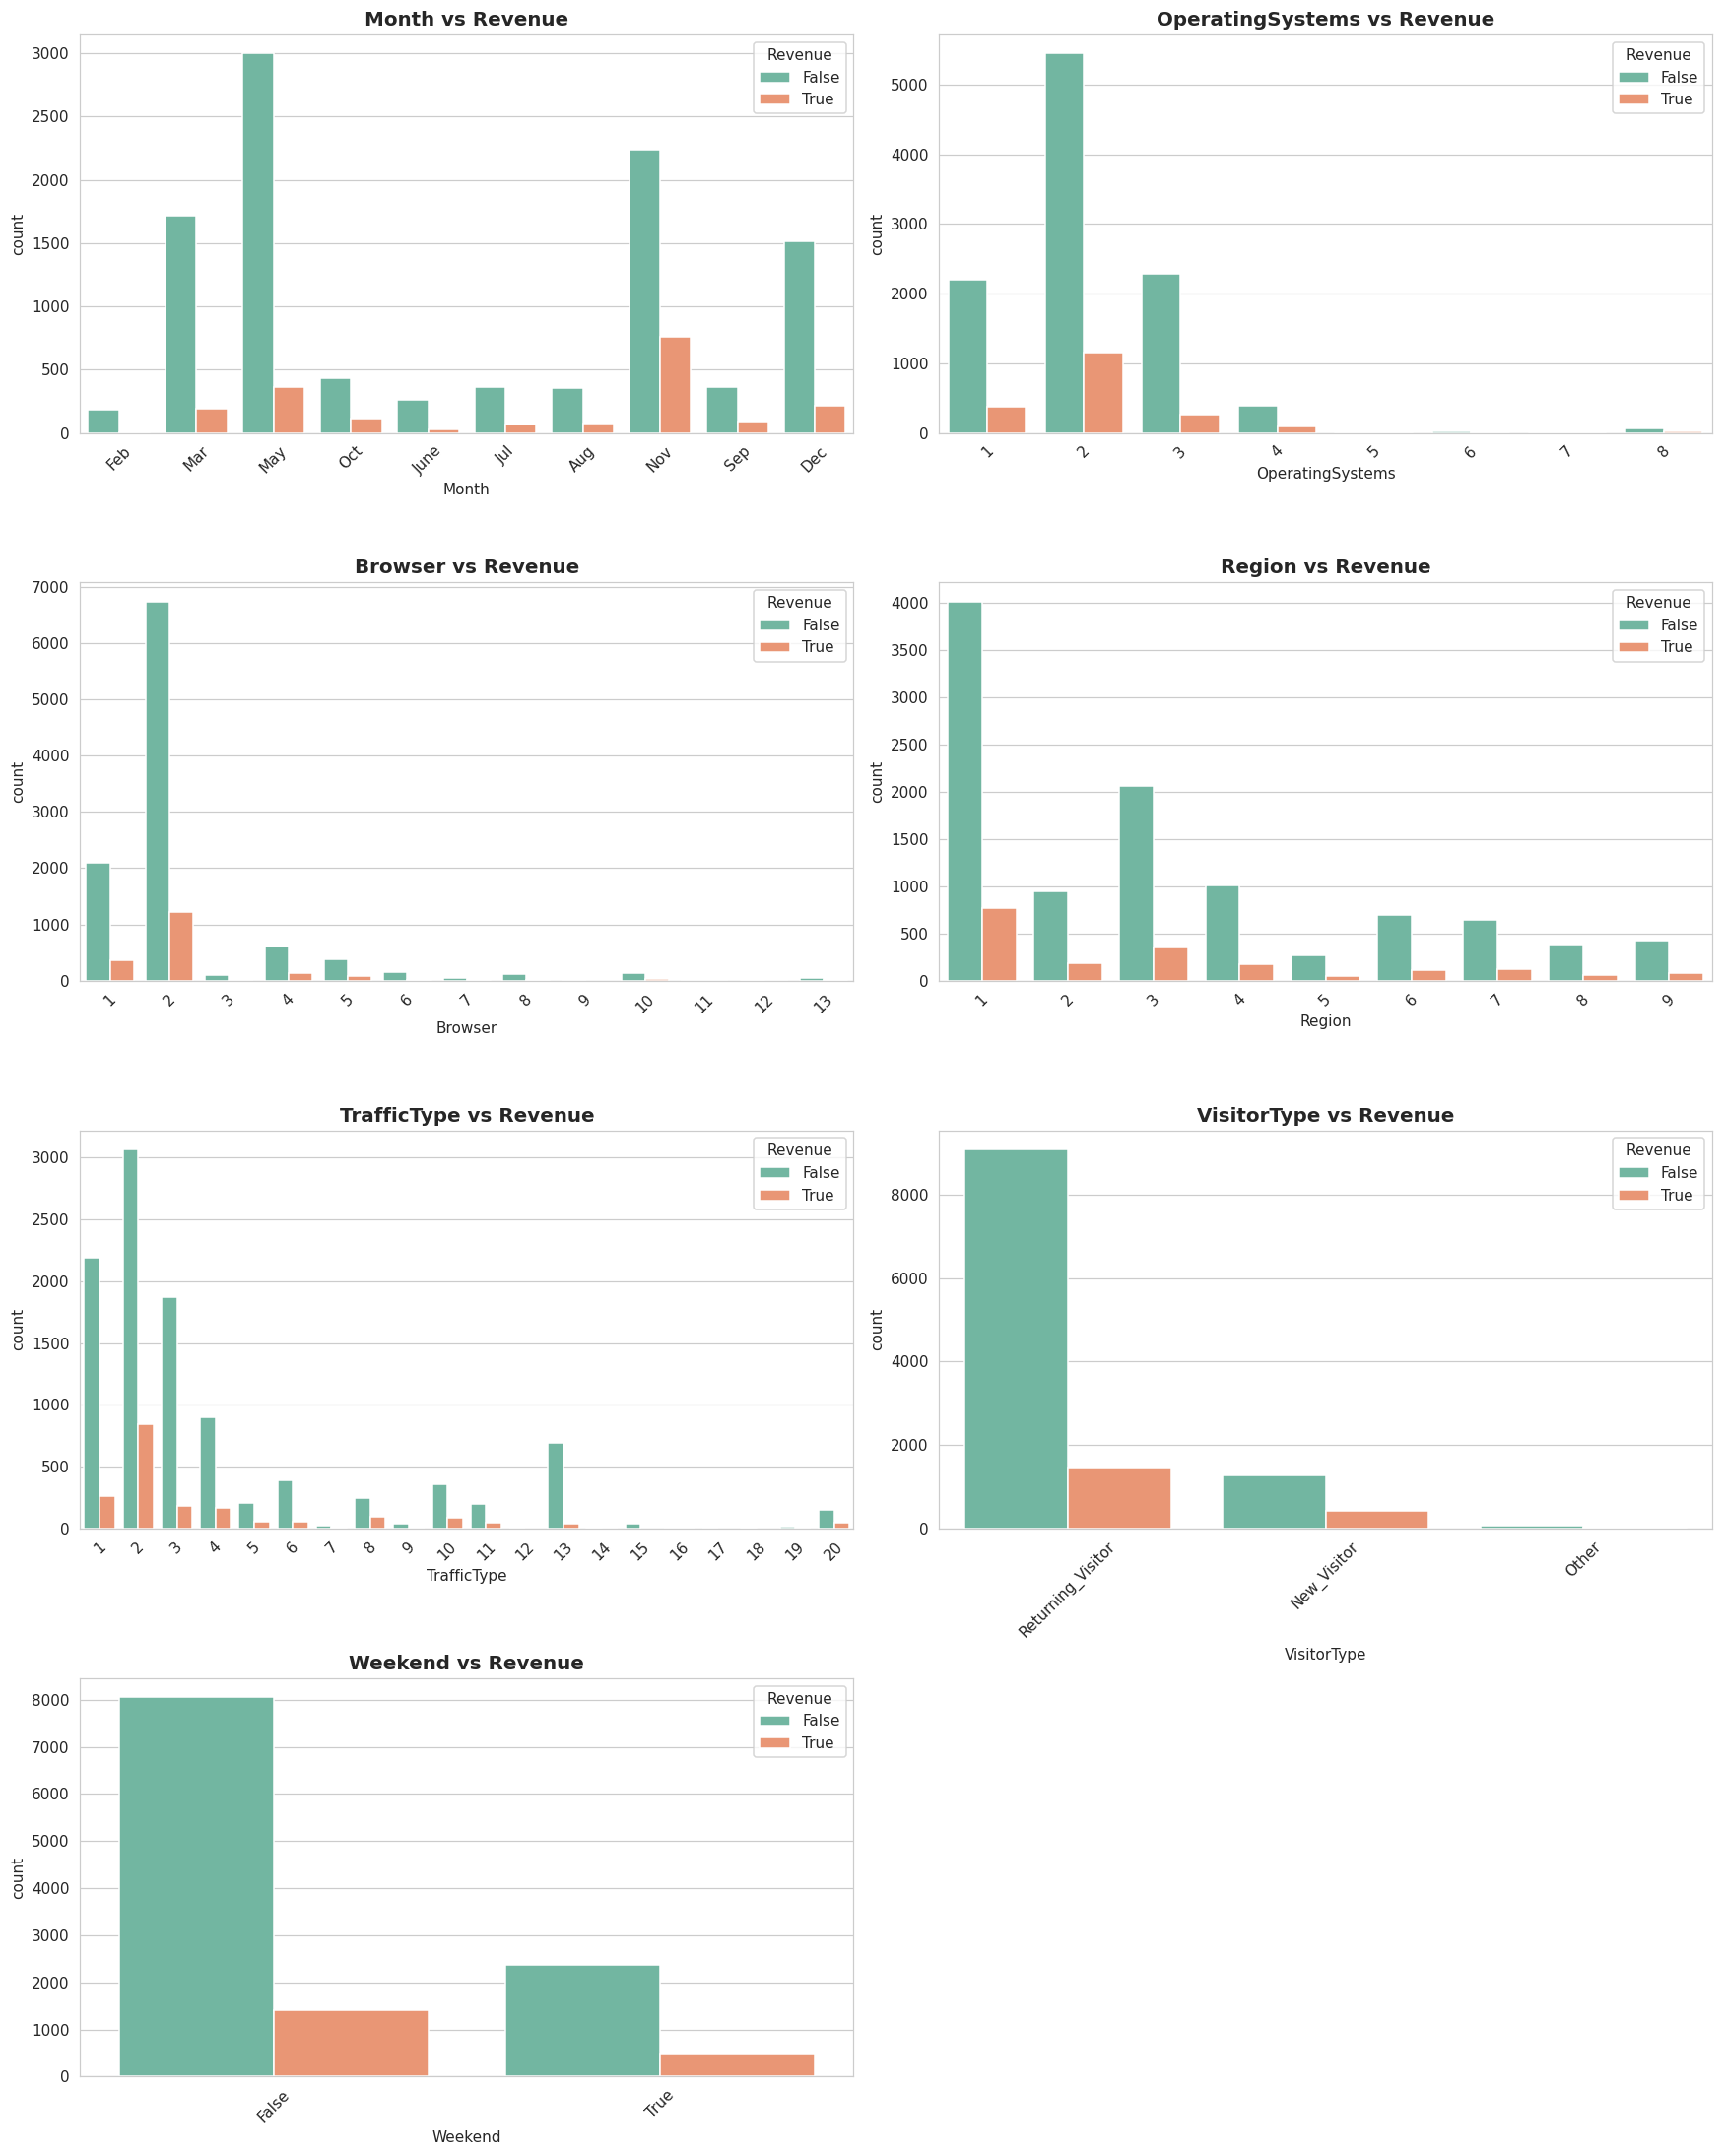

In [7]:
cat_cols = ["Month", "OperatingSystems", "Browser", "Region", "TrafficType",
            "VisitorType", "Weekend"]

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue="Revenue", ax=axes[i], palette="Set2")
    axes[i].set_title(f"{col} vs Revenue")
    axes[i].tick_params(axis="x", rotation=45)
fig.delaxes(axes[-1])
plt.tight_layout()
plt.savefig("figures/04_categorical_countplots.png")
plt.show()

## correlation matrix

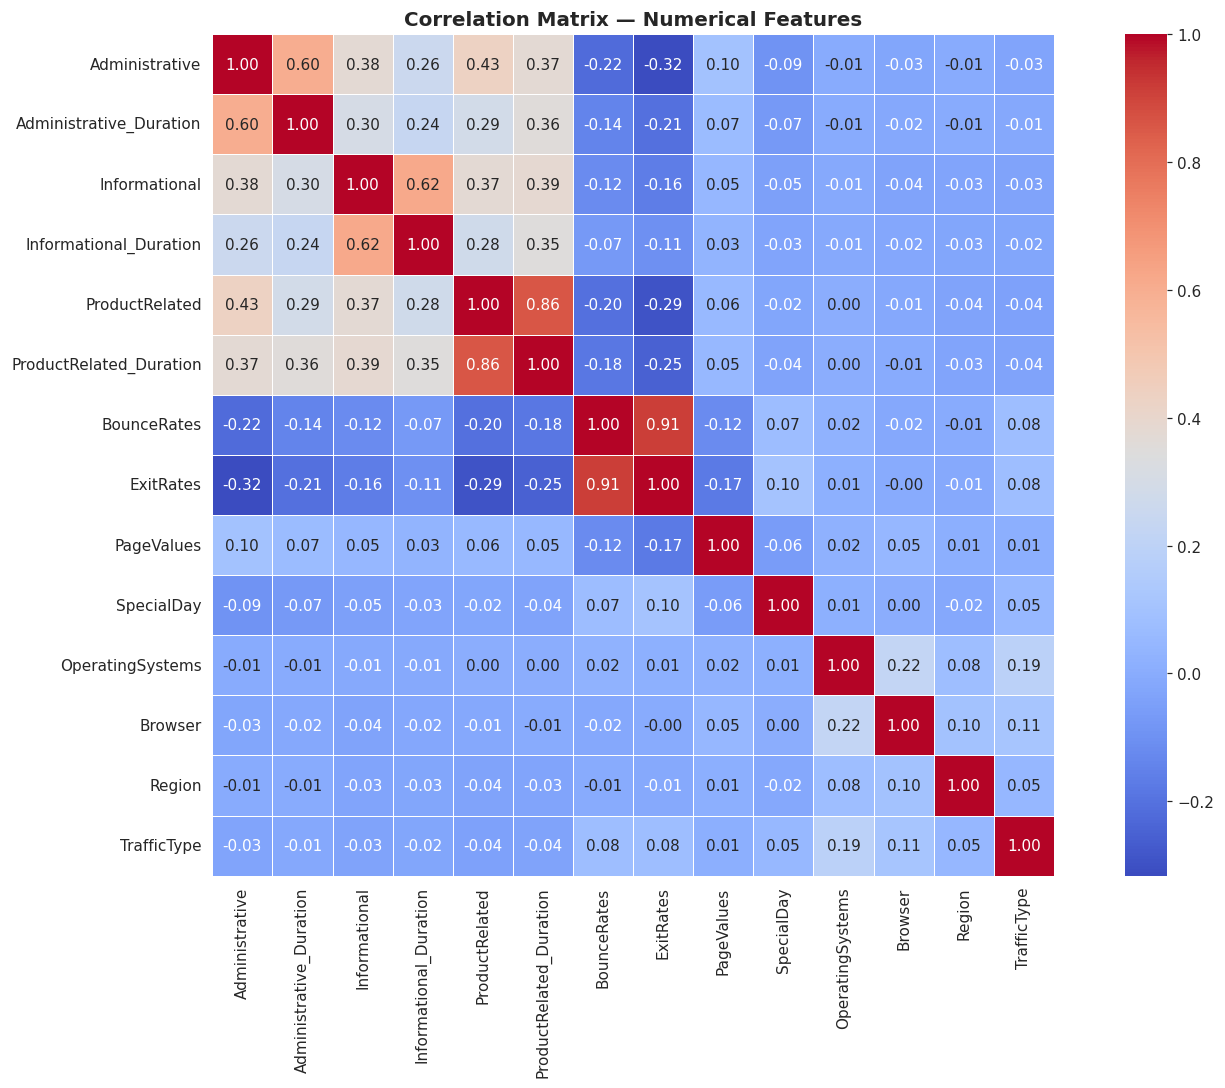

In [8]:
plt.figure(figsize=(14, 10))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Correlation Matrix — Numerical Features")
plt.tight_layout()
plt.savefig("figures/05_correlation_matrix.png")
plt.show()

## boxplots & violin plots

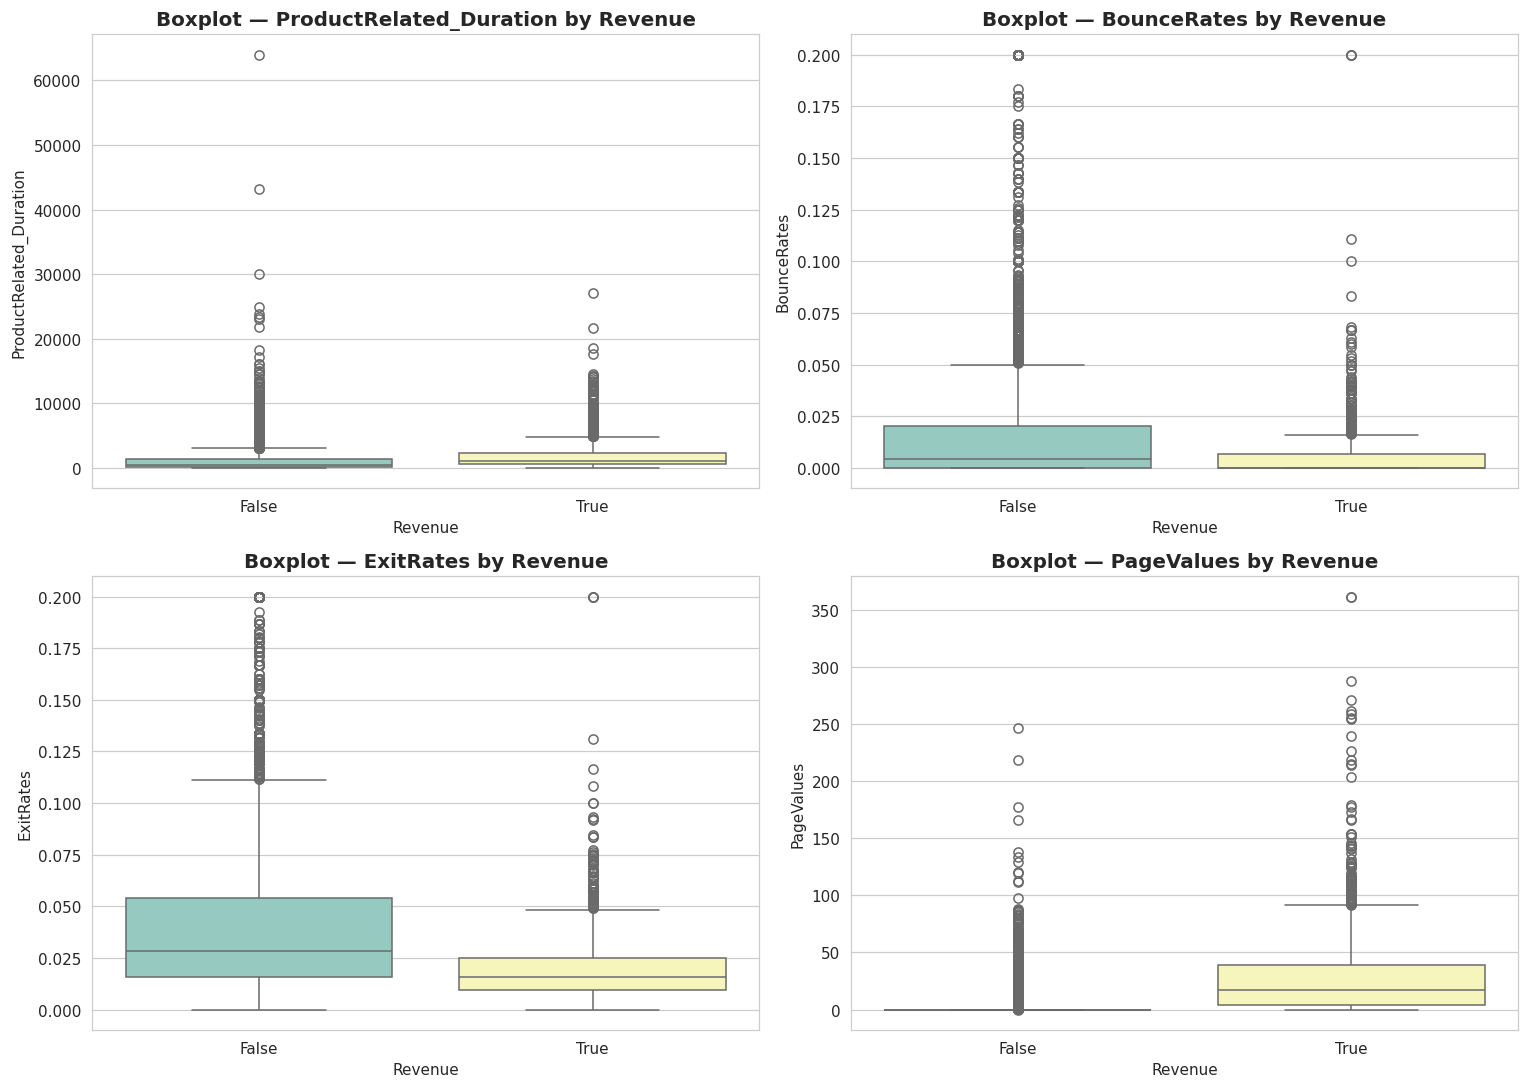

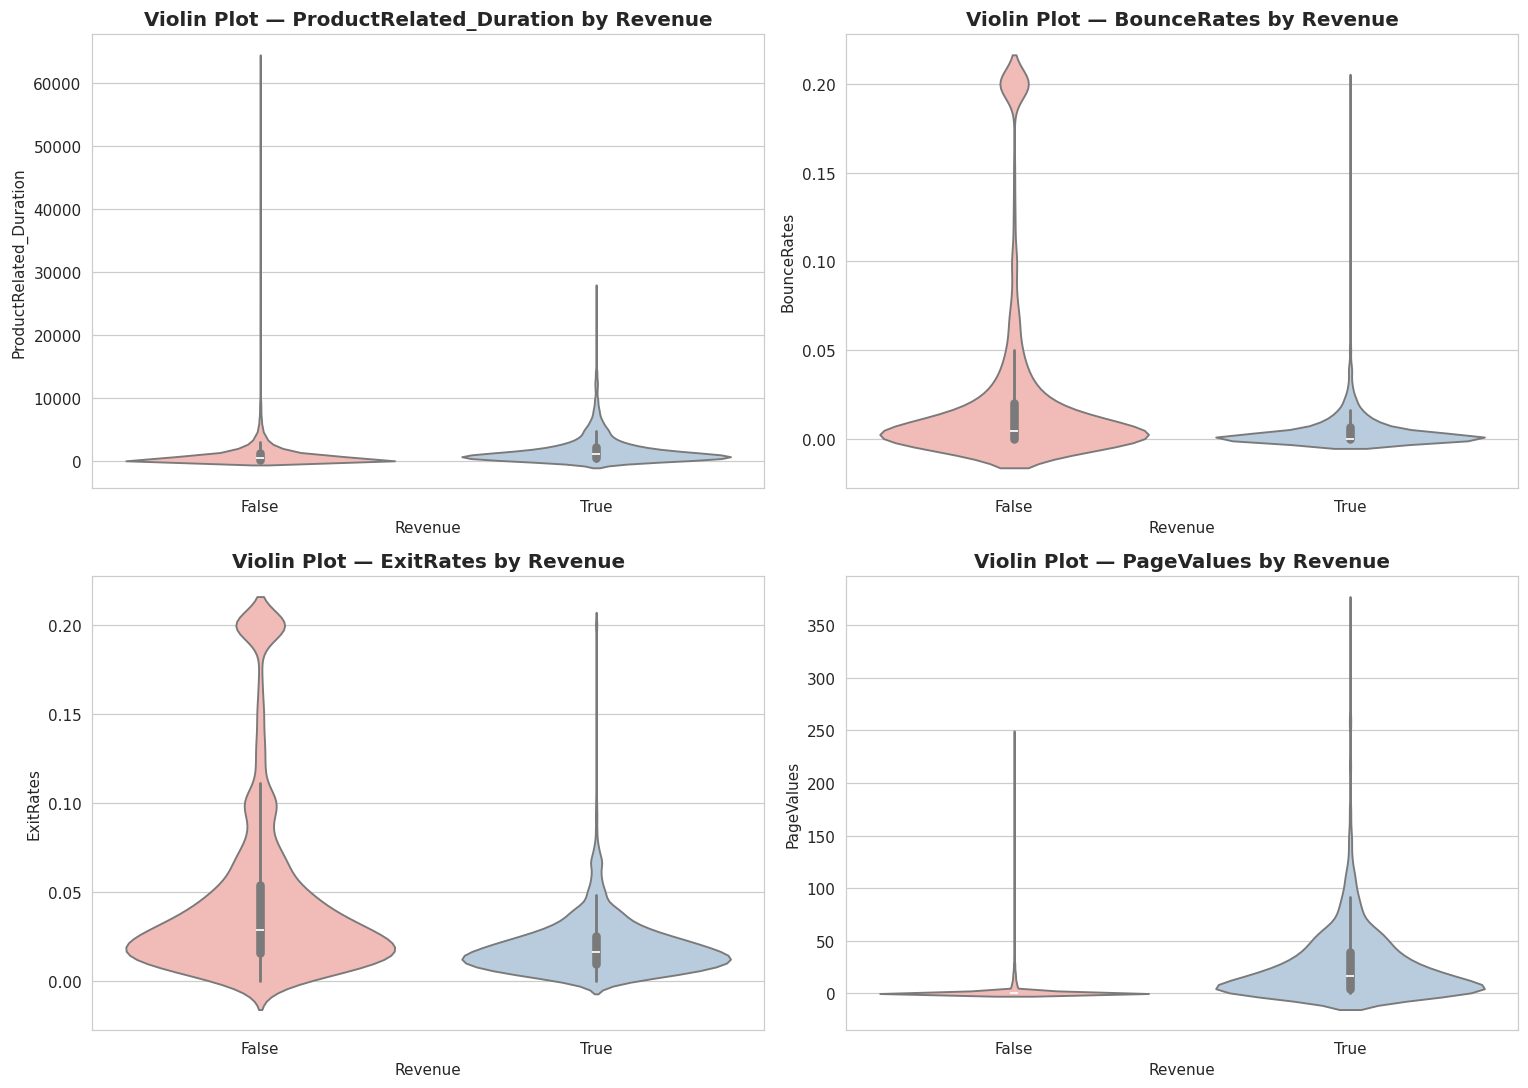

In [9]:
key_features = ["ProductRelated_Duration", "BounceRates", "ExitRates", "PageValues"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(key_features):
    sns.boxplot(data=df, x="Revenue", y=col, ax=axes[i], palette="Set3")
    axes[i].set_title(f"Boxplot — {col} by Revenue")
plt.tight_layout()
plt.savefig("figures/06_boxplots.png")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(key_features):
    sns.violinplot(data=df, x="Revenue", y=col, ax=axes[i], palette="Pastel1")
    axes[i].set_title(f"Violin Plot — {col} by Revenue")
plt.tight_layout()
plt.savefig("figures/07_violinplots.png")
plt.show()

# Data Cleaning

In [10]:
df_clean = df.copy()

# Remove duplicates
before = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f"Removed {before - len(df_clean)} duplicate rows.")

# Handle missing values (median for numeric, mode for categorical)
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        if df_clean[col].dtype in [np.float64, np.int64]:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
        else:
            df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

# Convert boolean columns
df_clean["Weekend"] = df_clean["Weekend"].astype(bool).astype(int)
df_clean["Revenue"] = df_clean["Revenue"].astype(bool).astype(int)

# Correct data types
int_like_cols = ["OperatingSystems", "Browser", "Region", "TrafficType"]
for col in int_like_cols:
    df_clean[col] = df_clean[col].astype(int)

print("Missing values after cleaning:", df_clean.isnull().sum().sum())
print("Final shape:", df_clean.shape)
display(df_clean.dtypes)

Removed 125 duplicate rows.
Missing values after cleaning: 0
Final shape: (12205, 18)


,0
Administrative,int64
Administrative_Duration,float64
Informational,int64
Informational_Duration,float64
ProductRelated,int64
ProductRelated_Duration,float64
BounceRates,float64
ExitRates,float64
PageValues,float64
SpecialDay,float64


# Feature Engineering

In [11]:
def engineer_features(data):
    d = data.copy()

    # Interaction features
    d["Total_Pages_Viewed"] = d["Administrative"] + d["Informational"] + d["ProductRelated"]
    d["Total_Duration"] = (d["Administrative_Duration"] + d["Informational_Duration"]
                            + d["ProductRelated_Duration"])

    # Session duration ratio (avoid divide by zero)
    d["Avg_Duration_Per_Page"] = d["Total_Duration"] / d["Total_Pages_Viewed"].replace(0, np.nan)
    d["Avg_Duration_Per_Page"] = d["Avg_Duration_Per_Page"].fillna(0)

    # Browsing intensity: product pages relative to total pages
    d["ProductRelated_Ratio"] = d["ProductRelated"] / d["Total_Pages_Viewed"].replace(0, np.nan)
    d["ProductRelated_Ratio"] = d["ProductRelated_Ratio"].fillna(0)

    # Page efficiency: PageValues relative to exit rate
    d["Page_Efficiency"] = d["PageValues"] / (d["ExitRates"] + 1e-5)

    # Bounce-to-exit ratio
    d["Bounce_Exit_Ratio"] = d["BounceRates"] / (d["ExitRates"] + 1e-5)

    # Weekend behaviour flag interacting with visitor type
    d["Weekend_Returning"] = ((d["Weekend"] == 1) &
                               (d["VisitorType"] == "Returning_Visitor")).astype(int)

    # Month seasonality grouping
    holiday_months = ["Nov", "Dec", "May"]
    d["Is_Holiday_Season"] = d["Month"].isin(holiday_months).astype(int)

    return d

df_fe = engineer_features(df_clean)
print("New features created:")
new_cols = ["Total_Pages_Viewed", "Total_Duration", "Avg_Duration_Per_Page",
            "ProductRelated_Ratio", "Page_Efficiency", "Bounce_Exit_Ratio",
            "Weekend_Returning", "Is_Holiday_Season"]
display(df_fe[new_cols].head())

New features created:


,Total_Pages_Viewed,Total_Duration,Avg_Duration_Per_Page,ProductRelated_Ratio,Page_Efficiency,Bounce_Exit_Ratio,Weekend_Returning,Is_Holiday_Season
0,1,0.000000,0.000000,1.0,0.0,0.999950,0,0
1,2,64.000000,32.000000,1.0,0.0,0.000000,0,0
2,1,0.000000,0.000000,1.0,0.0,0.999950,0,0
3,2,2.666667,1.333333,1.0,0.0,0.357117,0,0
4,10,627.500000,62.750000,1.0,0.0,0.399920,1,0


## encoding and feature selection

In [12]:
df_encoded = pd.get_dummies(df_fe, columns=["Month", "VisitorType"], drop_first=True)

# convert any resulting bool columns to int
bool_cols = df_encoded.select_dtypes(include="bool").columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print("Shape after encoding:", df_encoded.shape)
display(df_encoded.head())

Shape after encoding: (12205, 35)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1


Low-variance features flagged: ['BounceRates', 'ExitRates', 'VisitorType_Other']


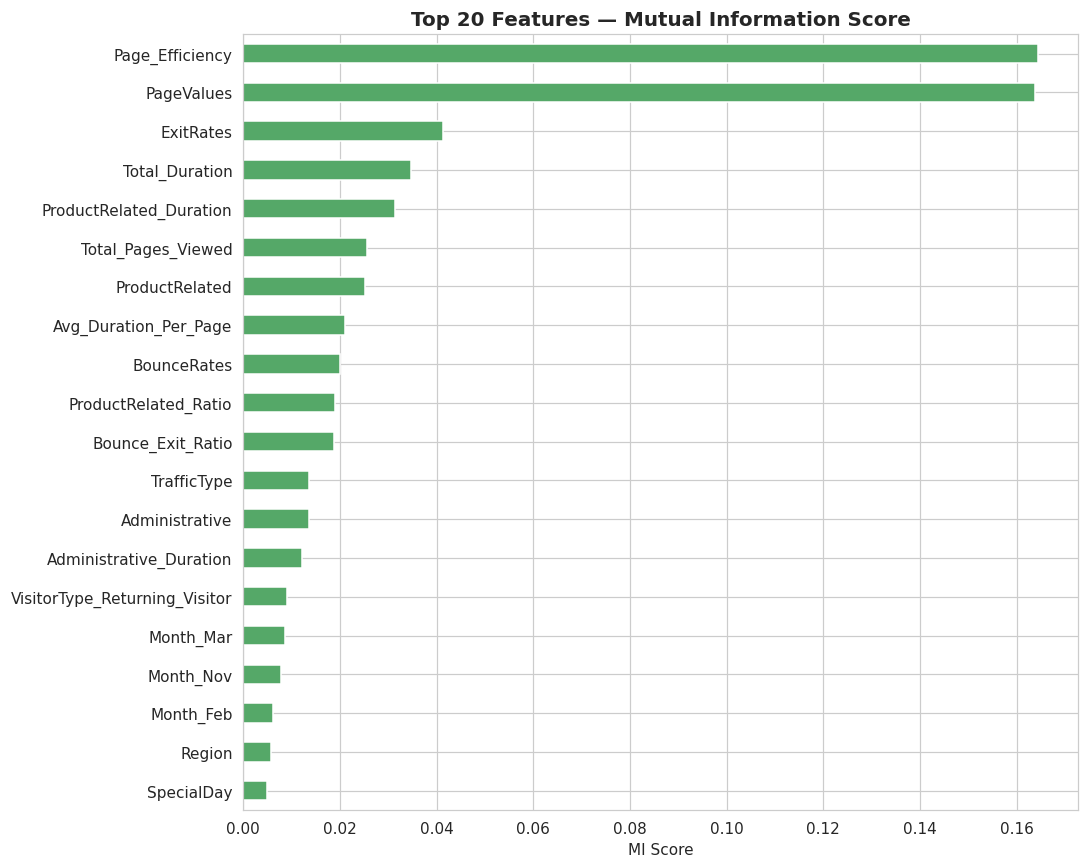


RFE selected features: ['Informational', 'BounceRates', 'ExitRates', 'SpecialDay', 'Weekend', 'ProductRelated_Ratio', 'Bounce_Exit_Ratio', 'Weekend_Returning', 'Month_Dec', 'Month_Feb', 'Month_June', 'Month_Mar', 'Month_May', 'Month_Nov', 'VisitorType_Returning_Visitor']

Final feature count: 31


In [13]:
X = df_encoded.drop(columns=["Revenue"])
y = df_encoded["Revenue"]

# Variance Threshold
vt = VarianceThreshold(threshold=0.01)
vt.fit(X)
low_var_features = X.columns[~vt.get_support()].tolist()
print("Low-variance features flagged:", low_var_features)

# Mutual Information
mi_scores = mutual_info_classif(X, y, random_state=RANDOM_SEED)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
mi_series.head(20).plot(kind="barh", color="#55A868")
plt.gca().invert_yaxis()
plt.title("Top 20 Features — Mutual Information Score")
plt.xlabel("MI Score")
plt.tight_layout()
plt.savefig("figures/11_mutual_information.png")
plt.show()

# Recursive Feature Elimination (using a light estimator for speed)
rfe_estimator = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
rfe = RFE(rfe_estimator, n_features_to_select=15)
rfe.fit(X, y)
rfe_selected = X.columns[rfe.support_].tolist()
print("\nRFE selected features:", rfe_selected)

# Drop near-zero-variance features only (keep everything else — models handle relevance)
X = X.drop(columns=[c for c in low_var_features if c in X.columns])
print("\nFinal feature count:", X.shape[1])

# Data Preprocessing

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_SEED
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True))

numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features)
    ],
    remainder="passthrough"
)

preprocessor.fit(X_train)
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

joblib.dump(preprocessor, "outputs/preprocessor.pkl")
print("Preprocessing pipeline saved.")

Train shape: (9764, 31)  Test shape: (2441, 31)
Train class balance:
 Revenue
0    0.843712
1    0.156288
Name: proportion, dtype: float64
Preprocessing pipeline saved.


# Machine Learning Models

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

param_grids = {
    "Logistic Regression": (
        LogisticRegression(max_iter=2000, random_state=RANDOM_SEED),
        {"C": [0.01, 0.1, 1, 10, 100], "penalty": ["l2"], "solver": ["lbfgs"]}
    ),
    "Decision Tree": (
        DecisionTreeClassifier(random_state=RANDOM_SEED),
        {"max_depth": [3, 5, 7, 10, 15, None],
         "min_samples_split": [2, 5, 10],
         "min_samples_leaf": [1, 2, 4]}
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=RANDOM_SEED),
        {"n_estimators": [100, 200, 300],
         "max_depth": [5, 10, 15, None],
         "min_samples_split": [2, 5, 10],
         "max_features": ["sqrt", "log2"]}
    ),
    "XGBoost": (
        xgb.XGBClassifier(random_state=RANDOM_SEED, eval_metric="logloss", use_label_encoder=False),
        {"n_estimators": [100, 200, 300],
         "max_depth": [3, 5, 7],
         "learning_rate": [0.01, 0.05, 0.1, 0.2],
         "subsample": [0.7, 0.8, 1.0]}
    ),
    "LightGBM": (
        LGBMClassifier(random_state=RANDOM_SEED, verbose=-1),
        {"n_estimators": [100, 200, 300],
         "max_depth": [3, 5, 7, -1],
         "learning_rate": [0.01, 0.05, 0.1, 0.2],
         "num_leaves": [15, 31, 63]}
    ),
}

trained_models = {}
model_results = []

for name, (estimator, grid) in param_grids.items():
    print(f"\nTraining: {name}")
    search = RandomizedSearchCV(
        estimator, grid, n_iter=15, cv=cv, scoring="roc_auc",
        random_state=RANDOM_SEED, n_jobs=-1, verbose=0
    )

    start_train = time.time()
    search.fit(X_train_processed, y_train)
    train_time = time.time() - start_train

    best_model = search.best_estimator_
    trained_models[name] = best_model

    start_pred = time.time()
    y_pred = best_model.predict(X_test_processed)
    pred_time = time.time() - start_pred

    y_proba = best_model.predict_proba(X_test_processed)[:, 1]
    cv_score = search.best_score_

    model_results.append({
        "Model": name,
        "Best Params": search.best_params_,
        "Training Time (s)": round(train_time, 3),
        "Prediction Time (s)": round(pred_time, 4),
        "CV ROC AUC": round(cv_score, 4),
        "y_pred": y_pred,
        "y_proba": y_proba
    })

    print(f"  Best Params: {search.best_params_}")
    print(f"  CV ROC AUC: {cv_score:.4f} | Train Time: {train_time:.2f}s | Pred Time: {pred_time:.4f}s")

print("\nAll models trained.")


Training: Logistic Regression
  Best Params: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 100}
  CV ROC AUC: 0.8913 | Train Time: 4.95s | Pred Time: 0.0006s

Training: Decision Tree
  Best Params: {'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 5}
  CV ROC AUC: 0.9148 | Train Time: 5.76s | Pred Time: 0.0071s

Training: Random Forest
  Best Params: {'n_estimators': 200, 'min_samples_split': 2, 'max_features': 'log2', 'max_depth': 10}
  CV ROC AUC: 0.9297 | Train Time: 196.70s | Pred Time: 0.0572s

Training: XGBoost
  Best Params: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05}
  CV ROC AUC: 0.9323 | Train Time: 37.03s | Pred Time: 0.0227s

Training: LightGBM
  Best Params: {'num_leaves': 15, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.01}
  CV ROC AUC: 0.9336 | Train Time: 26.92s | Pred Time: 0.0216s

All models trained.


# Model Evaluation

In [16]:
evaluation_rows = []

for res in model_results:
    name = res["Model"]
    y_pred = res["y_pred"]
    y_proba = res["y_proba"]

    evaluation_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_proba),
        "MCC": matthews_corrcoef(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "CV ROC AUC": res["CV ROC AUC"],
        "Training Time (s)": res["Training Time (s)"],
        "Prediction Time (s)": res["Prediction Time (s)"]
    })

    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(classification_report(y_test, y_pred))

comparison_df = pd.DataFrame(evaluation_rows).sort_values("ROC AUC", ascending=False).reset_index(drop=True)
comparison_df.insert(0, "Rank", range(1, len(comparison_df) + 1))
display(comparison_df.drop(columns=[]).style.background_gradient(subset=["ROC AUC", "Accuracy", "F1 Score"], cmap="Greens"))

comparison_df.to_csv("outputs/comparison_results.csv", index=False)


Logistic Regression
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      2059
           1       0.76      0.42      0.54       382

    accuracy                           0.89      2441
   macro avg       0.83      0.70      0.74      2441
weighted avg       0.88      0.89      0.87      2441


Decision Tree
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      2059
           1       0.70      0.61      0.65       382

    accuracy                           0.90      2441
   macro avg       0.81      0.78      0.80      2441
weighted avg       0.89      0.90      0.89      2441


Random Forest
              precision    recall  f1-score   support

           0       0.93      0.96      0.94      2059
           1       0.73      0.62      0.67       382

    accuracy                           0.90      2441
   macro avg       0.83      0.79      0.80      2441
weighted avg       0.90

,Rank,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,MCC,Balanced Accuracy,CV ROC AUC,Training Time (s),Prediction Time (s)
0,1,LightGBM,0.905367,0.752508,0.589005,0.660793,0.936140,0.612902,0.776533,0.933600,26.919000,0.021600
1,2,XGBoost,0.901680,0.711310,0.625654,0.665738,0.935765,0.610100,0.789272,0.932300,37.030000,0.022700
2,3,Random Forest,0.903318,0.725309,0.615183,0.665722,0.930190,0.612479,0.785979,0.929700,196.699000,0.057200
3,4,Decision Tree,0.897993,0.700906,0.607330,0.650771,0.920588,0.593484,0.779624,0.914800,5.761000,0.007100
4,5,Logistic Regression,0.888570,0.764423,0.416230,0.538983,0.909348,0.510680,0.696216,0.891300,4.954000,0.000600


## confusion matrices

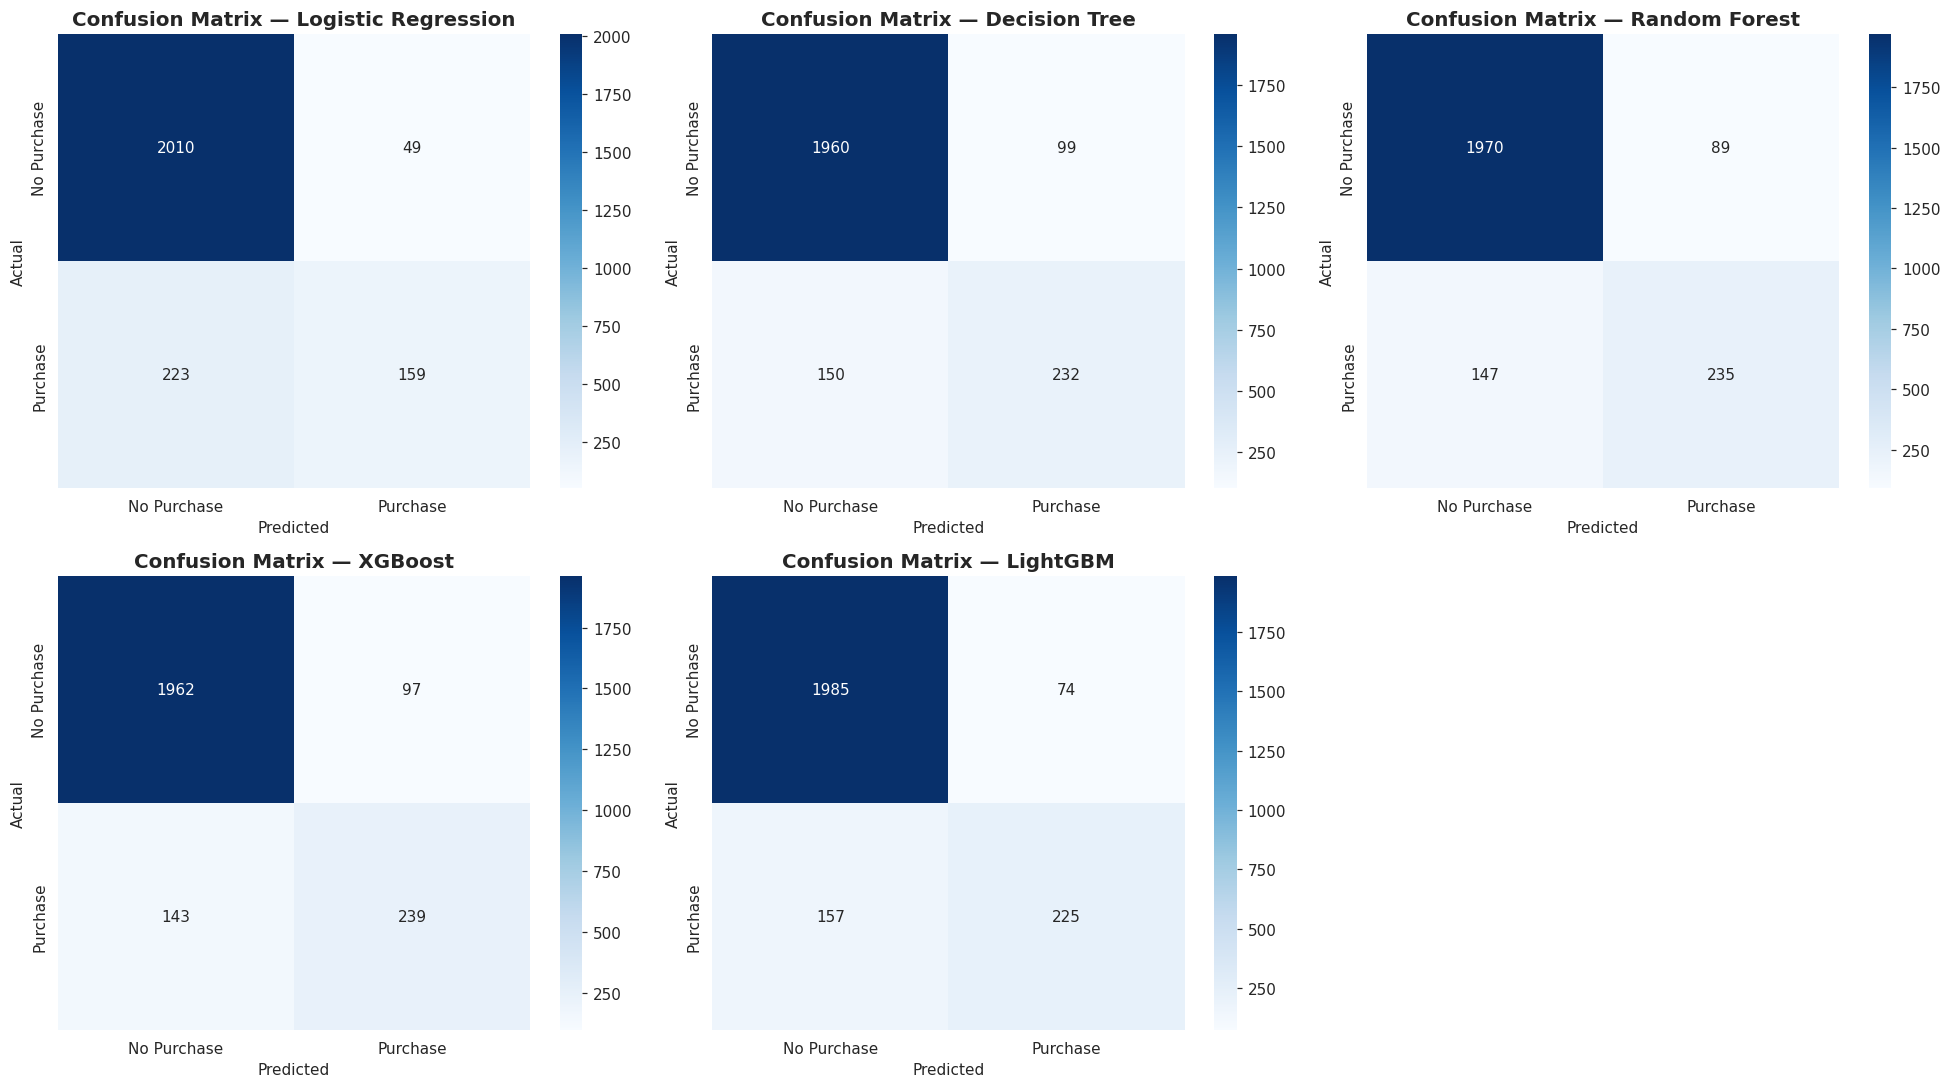

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, res in enumerate(model_results):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i],
                xticklabels=["No Purchase", "Purchase"], yticklabels=["No Purchase", "Purchase"])
    axes[i].set_title(f"Confusion Matrix — {res['Model']}")
    axes[i].set_xlabel("Predicted"); axes[i].set_ylabel("Actual")
fig.delaxes(axes[-1])
plt.tight_layout()
plt.savefig("figures/12_confusion_matrices.png")
plt.show()

## ROC curves & PR curves

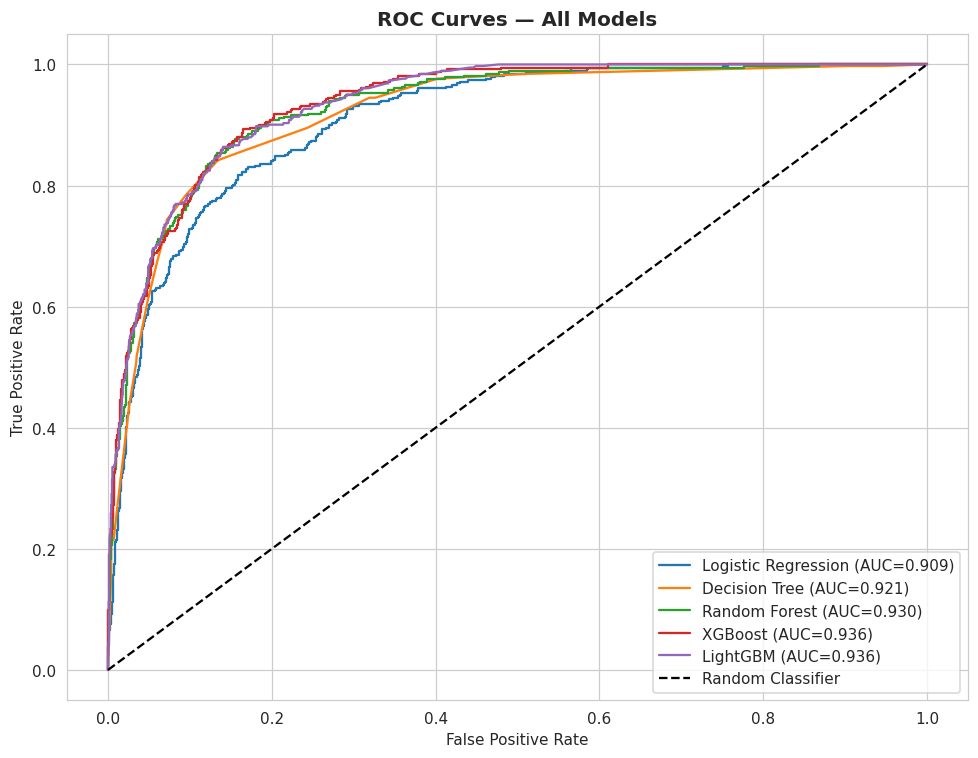

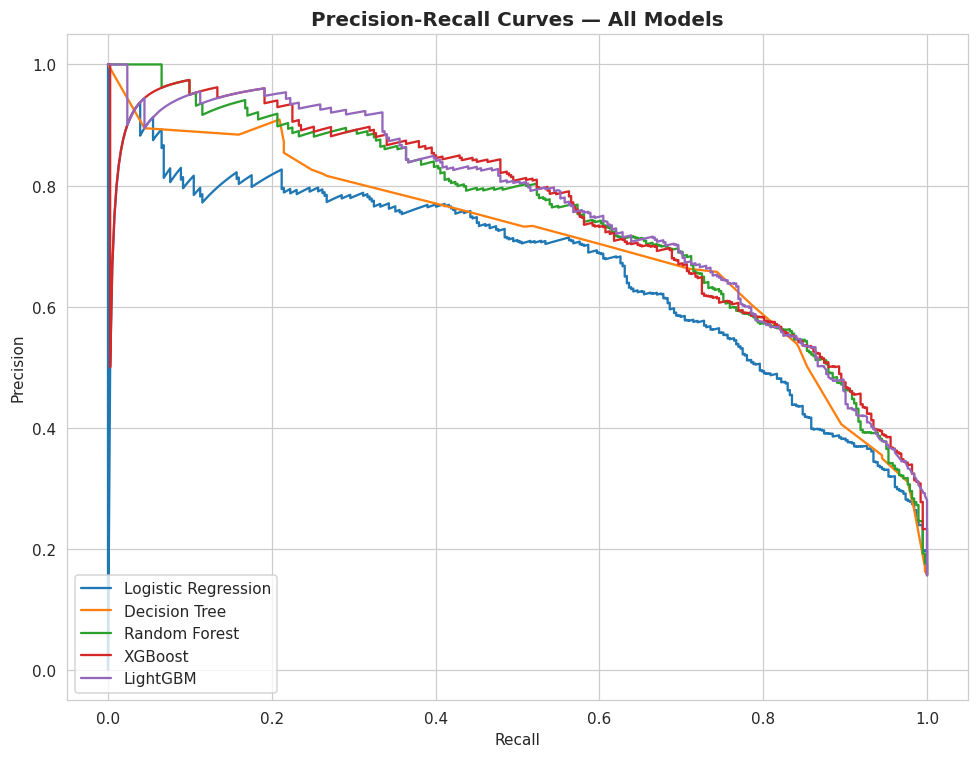

In [18]:
plt.figure(figsize=(9, 7))
for res in model_results:
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    auc_val = roc_auc_score(y_test, res["y_proba"])
    plt.plot(fpr, tpr, label=f"{res['Model']} (AUC={auc_val:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("figures/13_roc_curves.png")
plt.show()

plt.figure(figsize=(9, 7))
for res in model_results:
    prec, rec, _ = precision_recall_curve(y_test, res["y_proba"])
    plt.plot(rec, prec, label=res["Model"])
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall Curves — All Models")
plt.legend(loc="lower left")
plt.tight_layout()
plt.savefig("figures/14_pr_curves.png")
plt.show()

In [20]:
!pip install -q kaleido

In [22]:
metrics_long = comparison_df.melt(
    id_vars="Model", value_vars=["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"],
    var_name="Metric", value_name="Score"
)
fig = px.bar(metrics_long, x="Model", y="Score", color="Metric", barmode="group",
             title="Model Comparison Across Key Metrics", template="plotly_white")
fig.show()

In [23]:
best_row = comparison_df.iloc[0]
best_model_name = best_row["Model"]
best_model = trained_models[best_model_name]

print(f"Best Model Selected: {best_model_name}")
print(f"ROC AUC: {best_row['ROC AUC']:.4f}")
print(f"""
Justification: {best_model_name} achieved the highest ROC AUC ({best_row['ROC AUC']:.4f})
on the held-out test set, indicating the strongest ability to separate purchasing
from non-purchasing sessions across all probability thresholds. It also maintains
competitive Accuracy ({best_row['Accuracy']:.4f}) and F1 Score ({best_row['F1 Score']:.4f}),
and its cross-validated score ({best_row['CV ROC AUC']:.4f}) is consistent with the
test performance, suggesting good generalisation rather than overfitting.
""")

joblib.dump(best_model, "outputs/best_model.pkl")
print("Best model saved as outputs/best_model.pkl")

Best Model Selected: LightGBM
ROC AUC: 0.9361

Justification: LightGBM achieved the highest ROC AUC (0.9361)
on the held-out test set, indicating the strongest ability to separate purchasing
from non-purchasing sessions across all probability thresholds. It also maintains
competitive Accuracy (0.9054) and F1 Score (0.6608),
and its cross-validated score (0.9336) is consistent with the
test performance, suggesting good generalisation rather than overfitting.

Best model saved as outputs/best_model.pkl


# Explainability

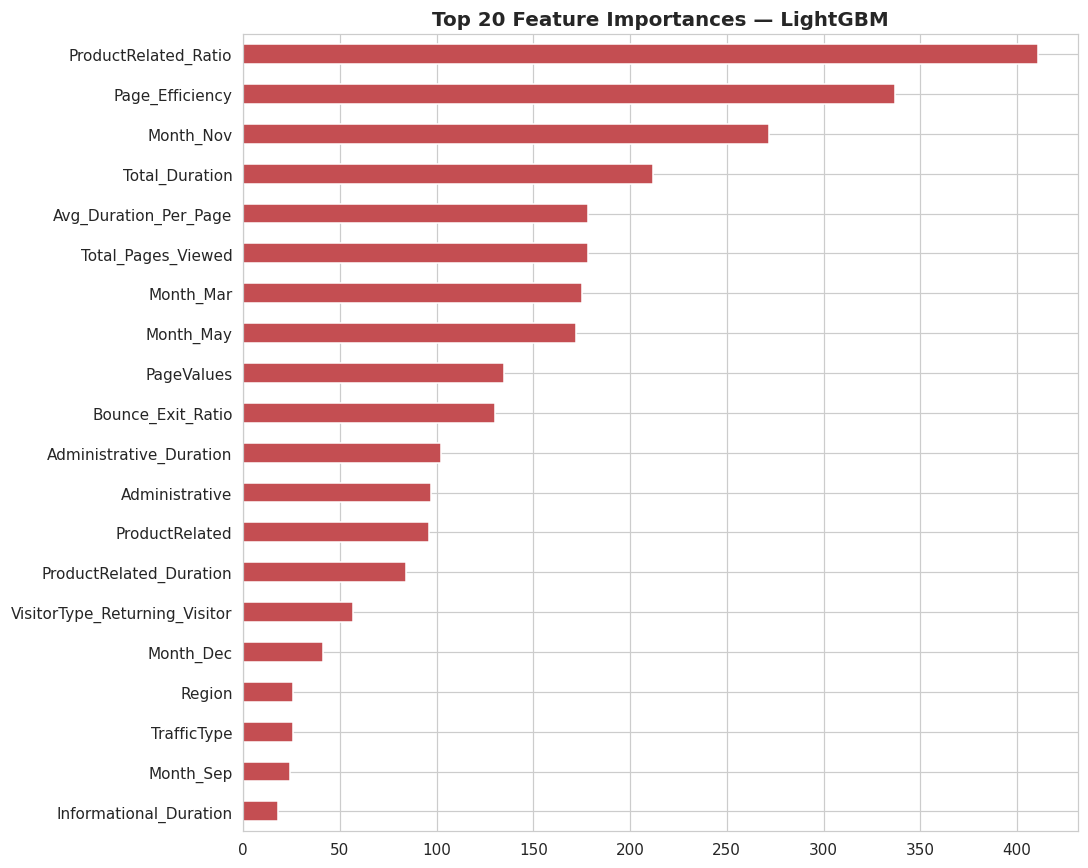

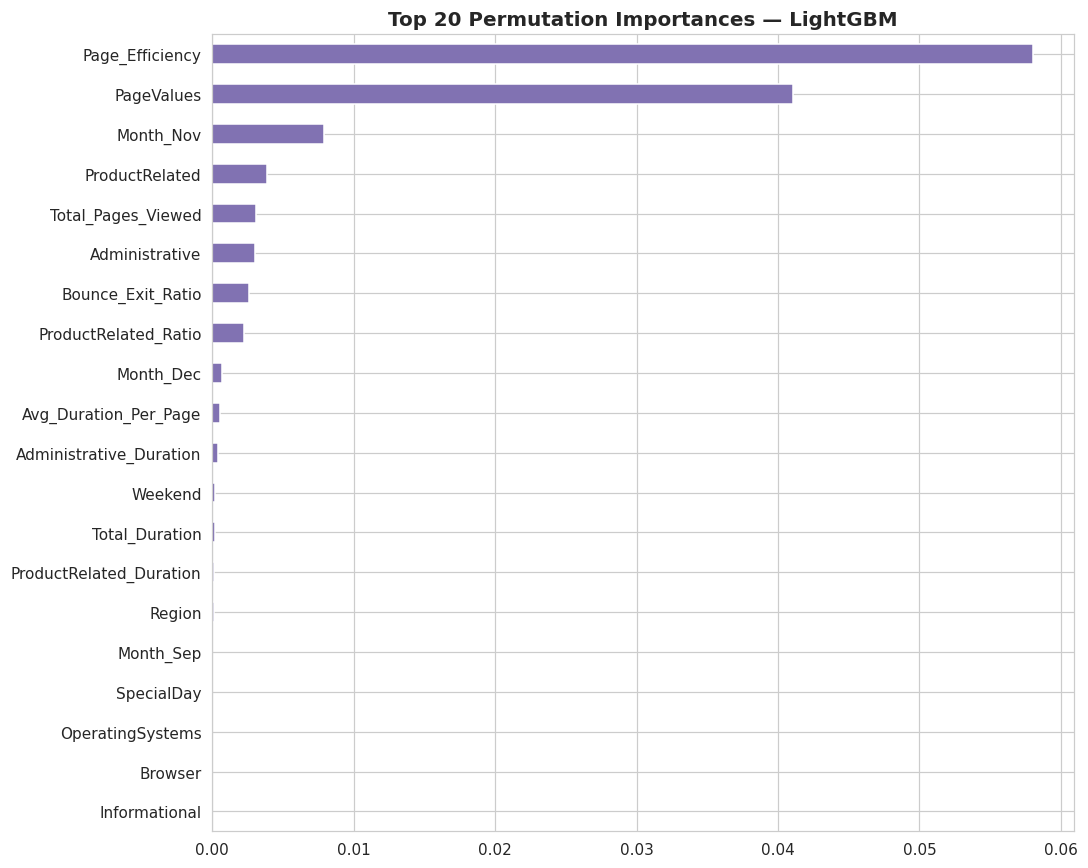

In [24]:
feature_names = numeric_features + [c for c in X.columns if c not in numeric_features]

if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
    imp_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)

    plt.figure(figsize=(10, 8))
    imp_series.head(20).plot(kind="barh", color="#C44E52")
    plt.gca().invert_yaxis()
    plt.title(f"Top 20 Feature Importances — {best_model_name}")
    plt.tight_layout()
    plt.savefig("figures/15_feature_importance.png")
    plt.show()

perm_result = permutation_importance(best_model, X_test_processed, y_test,
                                       n_repeats=10, random_state=RANDOM_SEED, n_jobs=-1)
perm_series = pd.Series(perm_result.importances_mean, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
perm_series.head(20).plot(kind="barh", color="#8172B2")
plt.gca().invert_yaxis()
plt.title(f"Top 20 Permutation Importances — {best_model_name}")
plt.tight_layout()
plt.savefig("figures/16_permutation_importance.png")
plt.show()

# SHAP

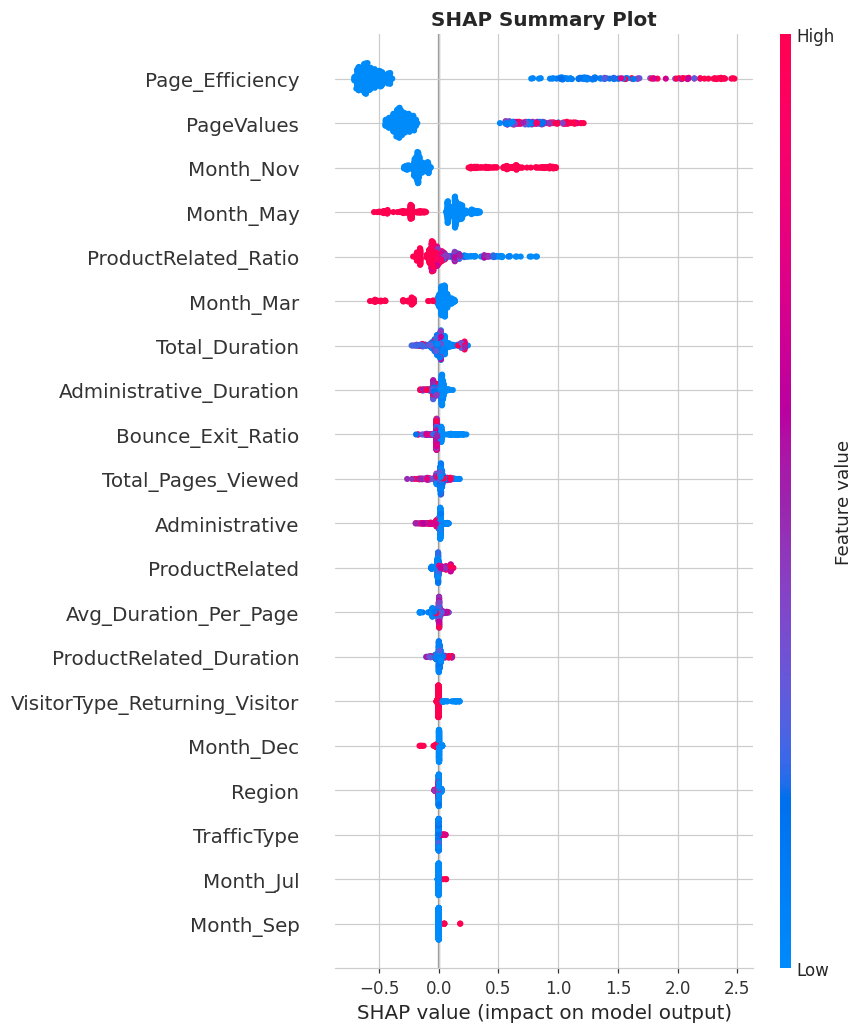

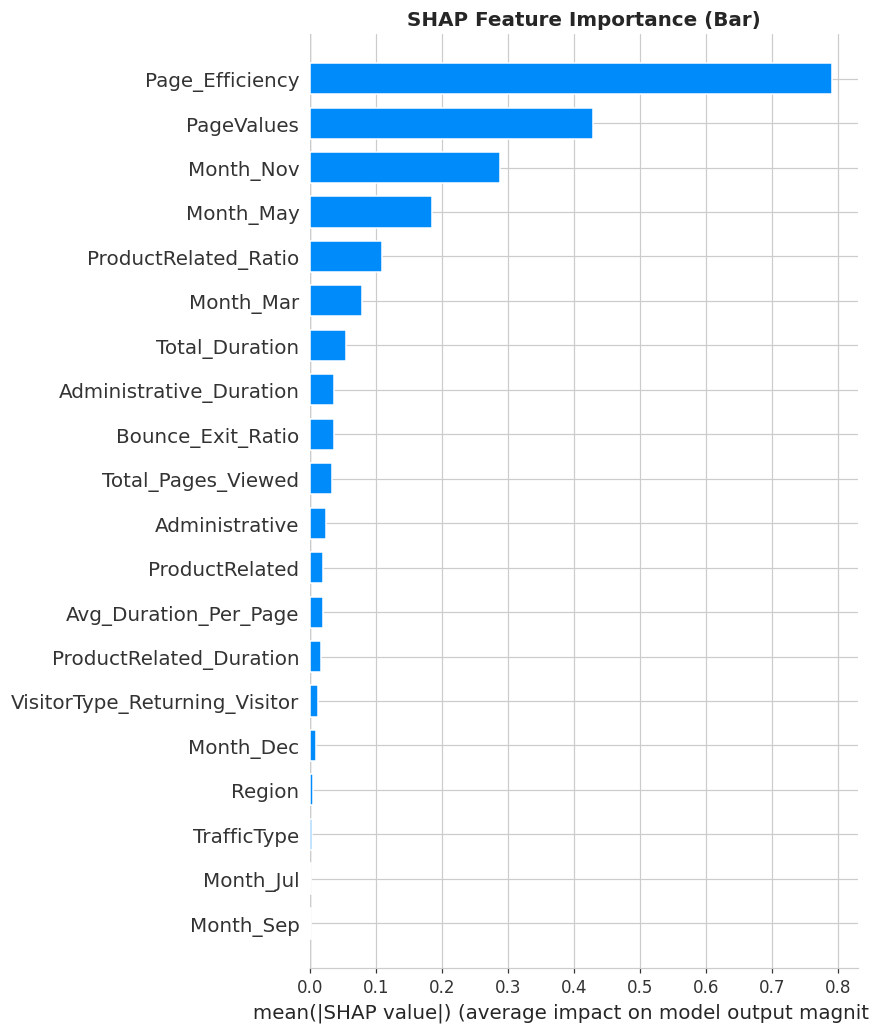

In [25]:
explainer = shap.Explainer(best_model, X_train_processed, feature_names=feature_names)
shap_values = explainer(X_test_processed[:500])   # subsample for speed

plt.figure()
shap.summary_plot(shap_values, X_test_processed[:500], feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.savefig("figures/18_shap_summary.png")
plt.show()

plt.figure()
shap.summary_plot(shap_values, X_test_processed[:500], feature_names=feature_names,
                   plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Bar)")
plt.tight_layout()
plt.savefig("figures/19_shap_bar.png")
plt.show()

# Error Analysis

False Positives: 74
False Negatives: 157
Total Misclassified: 231 (9.46%)


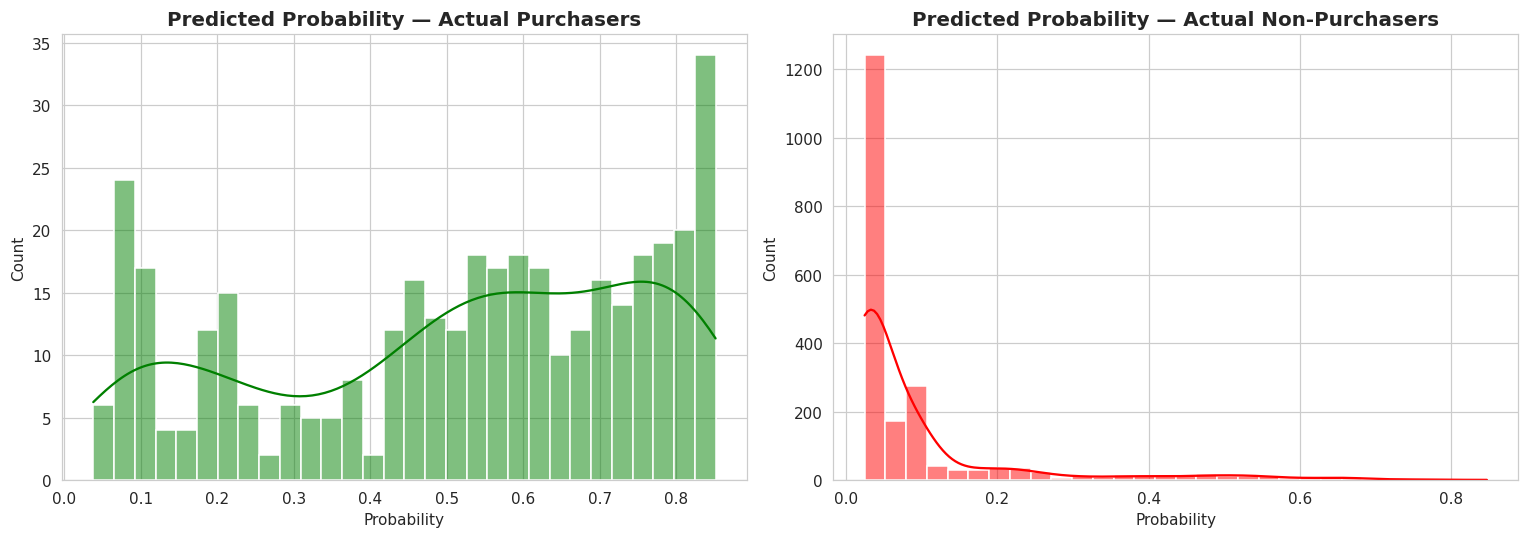


Sample misclassified rows:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,PageValues,SpecialDay,OperatingSystems,Browser,...,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Returning_Visitor,Actual,Predicted,Probability
9878,11,250.250000,0,0.0,169,8276.292565,8.174729,0.0,4,1,...,0,0,0,1,0,0,1,0,1,0.561414
9159,4,196.500000,3,72.5,245,7569.248612,4.770910,0.0,3,2,...,0,0,0,1,0,0,1,0,1,0.569936
1793,3,31.600000,0,0.0,17,372.800000,2.397600,0.0,3,2,...,0,1,0,0,0,0,1,0,1,0.572464
7769,10,471.060000,0,0.0,171,5830.910000,0.000000,0.0,2,10,...,0,0,0,0,1,0,1,1,0,0.039973
4829,4,133.583333,2,64.0,67,1222.470924,6.094324,0.0,3,2,...,0,0,1,0,0,0,1,1,0,0.289562
7731,9,266.743333,4,1312.4,26,743.476667,9.284546,0.0,2,7,...,0,0,0,1,0,0,1,1,0,0.369908
1382,0,0.000000,0,0.0,10,130.166667,26.661333,0.0,3,2,...,0,1,0,0,0,0,1,0,1,0.670141
10024,3,68.285714,0,0.0,26,741.055556,13.246672,0.0,3,2,...,0,0,0,1,0,0,1,1,0,0.472760
11430,10,302.083333,0,0.0,81,1778.663263,16.437847,0.0,1,1,...,0,0,0,1,0,0,0,0,1,0.608010
10195,7,51.708333,2,280.5,149,7569.182143,11.377261,0.0,2,2,...,0,0,0,1,0,0,1,1,0,0.492652


In [26]:
best_pred = None
for res in model_results:
    if res["Model"] == best_model_name:
        best_pred = res
        break

y_pred_best = best_pred["y_pred"]
y_proba_best = best_pred["y_proba"]

results_df = X_test.copy()
results_df["Actual"] = y_test.values
results_df["Predicted"] = y_pred_best
results_df["Probability"] = y_proba_best

false_positives = results_df[(results_df["Actual"] == 0) & (results_df["Predicted"] == 1)]
false_negatives = results_df[(results_df["Actual"] == 1) & (results_df["Predicted"] == 0)]
misclassified = results_df[results_df["Actual"] != results_df["Predicted"]]

print(f"False Positives: {len(false_positives)}")
print(f"False Negatives: {len(false_negatives)}")
print(f"Total Misclassified: {len(misclassified)} ({len(misclassified)/len(results_df)*100:.2f}%)")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(results_df[results_df["Actual"] == 1]["Probability"], bins=30, color="green",
             ax=ax[0], kde=True)
ax[0].set_title("Predicted Probability — Actual Purchasers")
sns.histplot(results_df[results_df["Actual"] == 0]["Probability"], bins=30, color="red",
             ax=ax[1], kde=True)
ax[1].set_title("Predicted Probability — Actual Non-Purchasers")
plt.tight_layout()
plt.savefig("figures/20_probability_distributions.png")
plt.show()

results_df.to_csv("outputs/predictions.csv", index=False)
print("\nSample misclassified rows:")
display(misclassified.head(10))

# Streamlit App Preparation, Build & Deployment Files

In [27]:
app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import plotly.graph_objects as go

st.set_page_config(page_title="Online Shopper Purchase Predictor", layout="wide", page_icon="🛒")

@st.cache_resource
def load_artifacts():
    model = joblib.load("best_model.pkl")
    preprocessor = joblib.load("preprocessor.pkl")
    return model, preprocessor

model, preprocessor = load_artifacts()

st.title("🛒 Online Shopper Purchase Intention Predictor")
st.markdown("Predict whether a browsing session will end in a purchase, using a trained ML model.")

st.sidebar.header("Session Input Features")

def user_input():
    admin = st.sidebar.number_input("Administrative pages viewed", 0, 30, 0)
    admin_dur = st.sidebar.number_input("Administrative duration (s)", 0.0, 3000.0, 0.0)
    info = st.sidebar.number_input("Informational pages viewed", 0, 30, 0)
    info_dur = st.sidebar.number_input("Informational duration (s)", 0.0, 3000.0, 0.0)
    product = st.sidebar.number_input("Product related pages viewed", 0, 700, 1)
    product_dur = st.sidebar.number_input("Product related duration (s)", 0.0, 15000.0, 0.0)
    bounce = st.sidebar.slider("Bounce rate", 0.0, 0.2, 0.02)
    exit_rate = st.sidebar.slider("Exit rate", 0.0, 0.2, 0.02)
    page_values = st.sidebar.number_input("Page values", 0.0, 400.0, 0.0)
    special_day = st.sidebar.slider("Special day closeness", 0.0, 1.0, 0.0)
    weekend = st.sidebar.checkbox("Weekend session")
    visitor_type = st.sidebar.selectbox("Visitor type", ["Returning_Visitor", "New_Visitor", "Other"])
    month = st.sidebar.selectbox("Month", ["Feb","Mar","May","June","Jul","Aug","Sep","Oct","Nov","Dec"])
    os_ = st.sidebar.number_input("Operating system code", 1, 8, 1)
    browser = st.sidebar.number_input("Browser code", 1, 13, 1)
    region = st.sidebar.number_input("Region code", 1, 9, 1)
    traffic = st.sidebar.number_input("Traffic type code", 1, 20, 1)

    total_pages = admin + info + product
    total_duration = admin_dur + info_dur + product_dur
    avg_dur_page = total_duration / total_pages if total_pages > 0 else 0
    product_ratio = product / total_pages if total_pages > 0 else 0
    page_eff = page_values / (exit_rate + 1e-5)
    bounce_exit_ratio = bounce / (exit_rate + 1e-5)
    weekend_returning = int(weekend and visitor_type == "Returning_Visitor")
    is_holiday = int(month in ["Nov", "Dec", "May"])

    data = {
        "Administrative": admin, "Administrative_Duration": admin_dur,
        "Informational": info, "Informational_Duration": info_dur,
        "ProductRelated": product, "ProductRelated_Duration": product_dur,
        "BounceRates": bounce, "ExitRates": exit_rate, "PageValues": page_values,
        "SpecialDay": special_day, "OperatingSystems": os_, "Browser": browser,
        "Region": region, "TrafficType": traffic, "Weekend": int(weekend),
        "Total_Pages_Viewed": total_pages, "Total_Duration": total_duration,
        "Avg_Duration_Per_Page": avg_dur_page, "ProductRelated_Ratio": product_ratio,
        "Page_Efficiency": page_eff, "Bounce_Exit_Ratio": bounce_exit_ratio,
        "Weekend_Returning": weekend_returning, "Is_Holiday_Season": is_holiday,
    }
    for m in ["Mar","May","June","Jul","Aug","Sep","Oct","Nov","Dec"]:
        data[f"Month_{m}"] = int(month == m)
    for v in ["New_Visitor", "Other"]:
        data[f"VisitorType_{v}"] = int(visitor_type == v)

    return pd.DataFrame([data])

input_df = user_input()

st.subheader("Session Feature Summary")
st.dataframe(input_df, use_container_width=True)

col1, col2 = st.columns([1, 1])
with col1:
    predict_clicked = st.button("🔮 Predict Purchase", use_container_width=True)
with col2:
    if st.button("🔄 Reset Inputs", use_container_width=True):
        st.rerun()

if predict_clicked:
    expected_cols = preprocessor.feature_names_in_ if hasattr(preprocessor, "feature_names_in_") else input_df.columns
    for col in expected_cols:
        if col not in input_df.columns:
            input_df[col] = 0
    input_df = input_df[expected_cols]

    X_proc = preprocessor.transform(input_df)
    proba = model.predict_proba(X_proc)[0][1]
    pred = int(proba >= 0.5)

    st.subheader("Prediction Result")
    label = "✅ Likely to Purchase" if pred == 1 else "❌ Unlikely to Purchase"
    st.markdown(f"### {label}")

    fig = go.Figure(go.Indicator(
        mode="gauge+number",
        value=proba * 100,
        title={"text": "Purchase Probability (%)"},
        gauge={"axis": {"range": [0, 100]},
               "bar": {"color": "#4C72B0"},
               "steps": [
                   {"range": [0, 40], "color": "#f8d7da"},
                   {"range": [40, 70], "color": "#fff3cd"},
                   {"range": [70, 100], "color": "#d4edda"}]}
    ))
    st.plotly_chart(fig, use_container_width=True)

    st.metric("Model Confidence", f"{max(proba, 1-proba)*100:.1f}%")

    result_df = input_df.copy()
    result_df["Predicted_Revenue"] = pred
    result_df["Purchase_Probability"] = proba
    st.download_button("⬇️ Download Prediction", result_df.to_csv(index=False),
                        file_name="prediction.csv", mime="text/csv")

st.markdown("---")
st.markdown("<center>Built for COM763 Advanced Machine Learning — Wrexham University</center>", unsafe_allow_html=True)
'''

with open("app.py", "w") as f:
    f.write(app_code)

print("app.py generated.")

app.py generated.


In [28]:
requirements_txt = """streamlit
scikit-learn
pandas
numpy
xgboost
lightgbm
joblib
plotly
"""
with open("requirements.txt", "w") as f:
    f.write(requirements_txt)

runtime_txt = "python-3.11\n"
with open("runtime.txt", "w") as f:
    f.write(runtime_txt)

readme_md = f"""# Online Shopper Purchase Intention Predictor

A Streamlit web app that predicts whether an online shopping session will
result in a purchase, using a **{best_model_name}** model trained on the
Online Shoppers Intention dataset.

## Files
- `app.py` — Streamlit application
- `best_model.pkl` — trained classifier
- `preprocessor.pkl` — fitted ColumnTransformer/StandardScaler pipeline
- `requirements.txt` — Python dependencies
- `runtime.txt` — Python runtime version

## Run locally
```bash
pip install -r requirements.txt
streamlit run app.py
```

## Deploy on Streamlit Community Cloud
1. Push this folder to a public GitHub repository.
2. Go to https://share.streamlit.io and sign in with GitHub.
3. Click "New app", select the repository, branch, and `app.py` as the entry point.
4. Click "Deploy". Streamlit Cloud installs `requirements.txt` and runs the app.
5. Your app will be live at `https://<your-app-name>.streamlit.app`.
"""
with open("README.md", "w") as f:
    f.write(readme_md)

print("requirements.txt, runtime.txt, and README.md generated.")

requirements.txt, runtime.txt, and README.md generated.
